# Pendulum equation

## Full Domain Learning

In [ ]:
import torch
from torch.utils.data import TensorDataset, ConcatDataset, Subset
from torch import Tensor
from data_utils import compute_prediction_difference, compute_prediction, extract_targets, extract_TensorDataset, X, U, TIMES
from plot_utils import plot_loss_comp, plot_model_stats, print_model_info, plot_points_grid, plot_model_stats_grid, print_model_performances, plot_model_performances, get_animation, plot_points
from load_store_utils import load_stats, resume_model
from train import start_train
from typing import List
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tqdm import tqdm
import numpy as np
# ----------------------
TRAIN = True
SAVE_PLOTS = True
CROSS_THE_RUBICON = True
ONLY_FINAL_TRAINING = False

PDE = "Pendulum"
PDE_NAME = "Pendulum"
SEED = 42

TIME_SAMPLING = "Const" # Const Log

TIME_INDEXES = [i for i in range(10)] # None
TIME_RESOLUTION = 1

ACTUAL_MODE = "PINN"
N_EPOCHS = 400
LR_MODE = "CosAnn" # CosAnn ExpDec

IC_MODE = "Separated" # Separated Excluded Joined
PDE_AT_T0 = True

FOURIER_FEATURES = True
IC_PARAMS_IN_INPUT = True
PDE_PARAMS_IN_INPUT = False

DWA_MODE = "Std"
CLIP_GRAD = True

DATASET_NAME = "varyIC"

# ----------------------
if "PINN" not in ACTUAL_MODE:
    MONITOR_CONFLICTS = False
else:
    MONITOR_CONFLICTS = True

if CLIP_GRAD:
    CLIP = "GradClip"
else:
    CLIP = "NoGradClip"

DIR = DATASET_NAME

os.makedirs(f"{PDE}/FullDomainLearning/{DIR}", exist_ok=True)

if PDE_PARAMS_IN_INPUT and IC_PARAMS_IN_INPUT:
    DIR += f"/PDE_IC_params_in_input"
elif PDE_PARAMS_IN_INPUT:
    DIR += f"/PDE_params_in_input"
elif IC_PARAMS_IN_INPUT:
    DIR += f"/IC_params_in_input"
else:
    DIR += f"/No_params_in_input"

os.makedirs(f"{PDE}/FullDomainLearning/{DIR}", exist_ok=True)

DATA = f"data/{DATASET_NAME}/{TIME_SAMPLING}TimeStep"

BATCH_SIZE_TRAIN = 1024
BATCH_SIZE_DEV = 1024

full_dataset = None
dev_dataset = None
train_dataset = None
val_dataset = None
intra_test_dataset = None
inter_test_dataset = None

/home/claudia/tesi/ANN_fisica/code/code/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Functions

In [2]:
def load_subsets(
        dataset: List[ConcatDataset[TensorDataset]],
        indicesss: Tensor|List[List[Tensor]]
    ) -> List[ConcatDataset[Subset]]:
    datasetss = []
    for indicess, task_ds in zip(indicesss, dataset):
        datasets = []
        for indices, time_ds in zip(indicess, task_ds.datasets):
            datasets.append(Subset(time_ds, indices))
        datasetss.append(ConcatDataset(datasets))
    return datasetss

def load_datasets(
        dataset: List[ConcatDataset[TensorDataset]],
        indicesss: Tensor|List[List[Tensor]],
        time_resolution: int = 1
    ) -> List[ConcatDataset[TensorDataset]]:
    datasetss = []
    for cds, indicess in zip(dataset, indicesss):
        datasets = []
        for i in range(0, len(indicess), time_resolution):
            ds = cds.datasets[i]
            indices = indicess[i]
        #for ds, indices in zip(cds.datasets, indicess):
            cols = [col[indices] for col in ds.tensors]
            datasets.append(TensorDataset(*cols))
        datasetss.append(ConcatDataset(datasets))
    return datasetss

def merge_ds(datasets: List[TensorDataset]) -> TensorDataset:
    cols = None   
    for ds in datasets:
        new_cols = list(ds.tensors)
        if cols is None:
            cols = new_cols
        else:
            for i, col in enumerate(new_cols):
                cols[i] = torch.cat([cols[i], col])
    return TensorDataset(*cols)

def prepare_dataset(datasets: List[ConcatDataset], time_instants: List[int] = None) -> ConcatDataset:
    if time_instants is None:
        n_snapshots = len(datasets[0].datasets)
        time_instants = [i for i in range(n_snapshots)]
    data = [None for _ in time_instants]
    for i in time_instants:
        data[i] = merge_ds([concat_ds.datasets[i] for concat_ds in datasets])
    return ConcatDataset(data)

In [3]:
indices = {}
for s in ["dev", "train", "val", "intra_test"]:
    if INDEX is None:
        indices[s] = torch.load(f"{PDE}/{DATA}/{s}_indices.pth")
    else:
        indices[s] = [torch.load(f"{PDE}/{DATA}/{s}_indices.pth")[INDEX]]
    print(f"--------------- {s} set ---------------")
    print(f"n_tasks: {len(indices[s])}")
    print(f"time_instants_per_task: {len(indices[s][0])}")
    print(f"spatial_points_per_time_instant: {len(indices[s][0][0])}")

--------------- dev set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 2048
--------------- train set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 1536
--------------- val set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 512
--------------- intra_test set ---------------
n_tasks: 1
time_instants_per_task: 10
spatial_points_per_time_instant: 512


In [4]:
if INDEX is None:
    full_dataset = torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets
else:
    full_dataset = [torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets[INDEX]]

dev_dataset = load_datasets(full_dataset, indices["dev"])
del full_dataset
full_dataset = None

train_dataset = load_datasets(dev_dataset, indices["train"], TIME_RESOLUTION)
val_dataset = load_datasets(dev_dataset, indices["val"], TIME_RESOLUTION)
del dev_dataset
dev_dataset = None

print(f"n_train_time_instants: {len(train_dataset[0].datasets)}")
print(f"n_val_time_instants: {len(val_dataset[0].datasets)}")

if TIME_INDEXES is not None:
    train_dataset = prepare_dataset(datasets=train_dataset, time_instants=TIME_INDEXES)
    val_dataset = prepare_dataset(datasets=val_dataset, time_instants=TIME_INDEXES)
else:
    train_dataset = prepare_dataset(datasets=train_dataset)
    val_dataset = prepare_dataset(datasets=val_dataset)

print(f"train set size: {len(train_dataset)}")
print(f"val set size: {len(val_dataset)}")

n_train_time_instants: 10
n_val_time_instants: 10
train set size: 15360
val set size: 5120


### 1st model selection step
Perform 20 trials of 10 epochs each.

In [5]:
if TRAIN:
    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models0"
    
    n_sources = N_SOURCES
    pde_params = ["D"]
    ic_params = ["u0"]
    for i in range(n_sources):
        ic_params.append(f"xc{i}")
        ic_params.append(f"yc{i}")
        ic_params.append(f"amp{i}")
        ic_params.append(f"sigma{i}")
    
    actual = {
        "mode": ACTUAL_MODE,
        "time_in_input": True,
        "space_in_input": True,
        "shape": SHAPE,
        "importance": 1.0,
        "bc_importance": 1.0,
        "ic_importance": 1.0,
        "BC": TRAIN_BC,
        "boundary": BC_MODE,
        "pde_at_bd": PDE_AT_BD,
        "pde_at_t0": PDE_AT_T0,
        "initial_time": IC_MODE,
        "monitor_conflicts": MONITOR_CONFLICTS,
        "train_dataset": train_dataset,
        "val_dataset": val_dataset
    }
    if IC_PARAMS_IN_INPUT:
        actual["ic_params_in_input"] = ic_params
    if PDE_PARAMS_IN_INPUT:
        actual["pde_params_in_input"] = pde_params
    if FOURIER_FEATURES:
        actual["fourier_features"] = [-1, 5, 10, 20, 30]
        actual["frequency_variance"] = [1, 3, 5, 7, 9]
    else:
        actual["fourier_features"] = -1
        actual["frequency_variance"] = 1.0
    
    distill = {
        "mode": "Forgetting",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0
    }
    ewc = {
        "mode": "Off",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0
    }
    dwa = {
        "mode": DWA_MODE,
        "moving_avg_factor": 0.9,
        "moving_avg_frequency": 1,#10,
        "warm_up": 3
    }
    config_dict = {
        "PDE": PDE_NAME,
        "Actual": actual,
        "Distillation": distill,
        "EWC": ewc,
        "DWA": dwa,
        "pruner": "median",
        "n_warmup_steps": 3,
        "threshold": 1.0,
        "n_trials": 10,
        "epochs": 10,
        "eval_every": 1,
        "seed": SEED,
        "device": "cpu",
        "learning_rate": [1e-2, 1e-3, 1e-4],#[1e-3, 1e-4, 1e-5],
        "scheduler": LR_MODE,
        "clip_grad": CLIP_GRAD,
        "batch_size": min(BATCH_SIZE_TRAIN, len(train_dataset)),
        "models_dir": models_dir,
        "suggestions": "On"
    }
    if not ONLY_FINAL_TRAINING:
        start_train(config_dict)

[I 2026-03-28 11:11:42,265] A new study created in memory with name: no-name-04d9a475-de1c-4190-b408-ffe6cec8b011


batch_size_train = 1024
len(train_dataset) = 14336
batch_size_val = 1024
len(val_dataset) = 4096
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 604
len(train_bc_dataset) = 604
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 200
len(val_bc_dataset) = 200

Epoch: 0, step_prefix: 0
Epoch time: 2.1954076290130615
train weighted loss: 61.16376713344029
train out loss: 13.114901610783168
val weighted loss: 70.89749526977539
val out loss: 13.516515254974365

Epoch: 1, step_prefix: 14
Epoch time: 2.0139386653900146
train weighted loss: 87.93014635358539
train out loss: 7.122630936758859
val weighted loss: 102.7657585144043
val out loss: 7.49584436416626

Epoch: 2, step_prefix: 28
Epoch time: 1.8423550128936768
train weighted loss: 64.81894738333565
train out loss: 4.312080417360578
val weighted loss: 76.93047332763672
val out loss: 4.662717819213867

Epoch: 3, step_prefix: 42
Epoch time: 1.8933994770050049
train weighted loss: 30.11695071629

[I 2026-03-28 11:12:18,449] Trial 0 finished with value: 7.4142954876006115 and parameters: {'lr_init': 0.001}. Best is trial 0 with value: 7.4142954876006115.


val weighted loss: 18.99816131591797
val out loss: 3.7245936393737793
batch_size_train = 1024
len(train_dataset) = 14336
batch_size_val = 1024
len(val_dataset) = 4096
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 604
len(train_bc_dataset) = 604
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 200
len(val_bc_dataset) = 200

Epoch: 0, step_prefix: 0
Epoch time: 2.0145652294158936
train weighted loss: 54.32959474836077
train out loss: 5.128275837217059
val weighted loss: 64.61016082763672
val out loss: 5.489837288856506

Epoch: 1, step_prefix: 14
Epoch time: 1.7688660621643066
train weighted loss: 27.958295685904368
train out loss: 4.161949276924133
val weighted loss: 33.356398582458496
val out loss: 4.509140849113464

Epoch: 2, step_prefix: 28
Epoch time: 1.790618896484375
train weighted loss: 21.402687072753906
train out loss: 3.4990161997931346
val weighted loss: 25.245341300964355
val out loss: 3.8076676726341248

Epoch: 3, step_pre

[I 2026-03-28 11:12:53,737] Trial 1 finished with value: 2.041995950974524 and parameters: {'lr_init': 0.01}. Best is trial 1 with value: 2.041995950974524.


...

val weighted loss: 111.31406211853027
val out loss: 20.104300022125244
batch_size_train = 1024
len(train_dataset) = 14336
batch_size_val = 1024
len(val_dataset) = 4096
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 604
len(train_bc_dataset) = 604
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 200
len(val_bc_dataset) = 200

Epoch: 0, step_prefix: 0
Epoch time: 1.9167354106903076
train weighted loss: 93.9823739188058
train out loss: 18.88156849997384
val weighted loss: 109.35853958129883
val out loss: 19.30305767059326

Epoch: 1, step_prefix: 14
Epoch time: 2.034621000289917
train weighted loss: 81.60756628853935
train out loss: 15.574335643223353
val weighted loss: 94.13081359863281
val out loss: 15.989097118377686

Epoch: 2, step_prefix: 28
Epoch time: 1.6580994129180908
train weighted loss: 115.23907470703125
train out loss: 10.23813806261335
val weighted loss: 134.5492935180664
val out loss: 10.626062154769897

Epoch: 3, step_pref

[I 2026-03-28 11:15:30,516] Trial 8 pruned. 


val weighted loss: 127.56729698181152
val out loss: 6.248222231864929
batch_size_train = 1024
len(train_dataset) = 14336
batch_size_val = 1024
len(val_dataset) = 4096
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 604
len(train_bc_dataset) = 604
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 200
len(val_bc_dataset) = 200

Epoch: 0, step_prefix: 0
Epoch time: 1.8656415939331055
train weighted loss: 102.69586835588727
train out loss: 18.400838988167898
val weighted loss: 119.63990020751953
val out loss: 18.82399559020996

Epoch: 1, step_prefix: 14
Epoch time: 2.15910267829895
train weighted loss: 89.02286693028041
train out loss: 14.318024158477783
val weighted loss: 102.58404922485352
val out loss: 14.725411176681519

Epoch: 2, step_prefix: 28
Epoch time: 1.6740379333496094
train weighted loss: 122.17474474225726
train out loss: 8.588560240609306
val weighted loss: 144.1288070678711
val out loss: 8.964982509613037

Epoch: 3, step_pre

[I 2026-03-28 11:15:44,282] Trial 9 pruned. 


val weighted loss: 113.62714385986328
val out loss: 5.410350441932678
Best trial params: {'lr_init': 0.01}
Best trial value: 2.041995950974524
trialN1 --> trial0: Objective Value = 2.0420
trialN4 --> trial1: Objective Value = 3.1487
trialN2 --> trial2: Objective Value = 7.3051
trialN0 --> trial3: Objective Value = 7.4143
trialN3 --> trial4: Objective Value = 23.8185


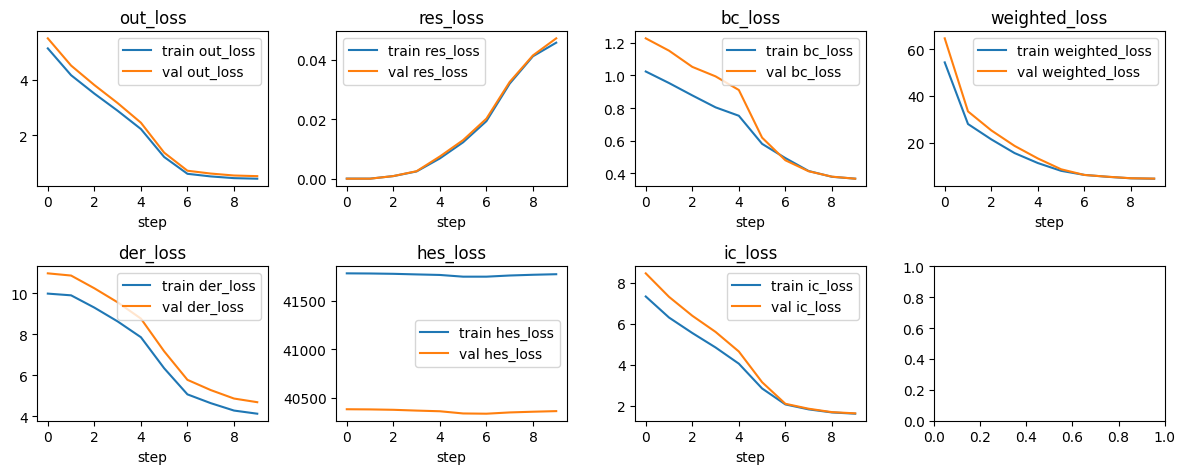


=============== Checkpoint ===============
PDE: Advection-Reaction-Diffusion
PDE parameters in input: []
Time in input: True
Space in input: True
Fourier features: -1
|Input units|: 3
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Forgetting
	EWC: Off
	DWA: Std
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 4.661065101623535
	IC: 1.5605026483535767
	RES: 7.424312114715576
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 1.0
	DER: 1.0
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importances:
---------------------

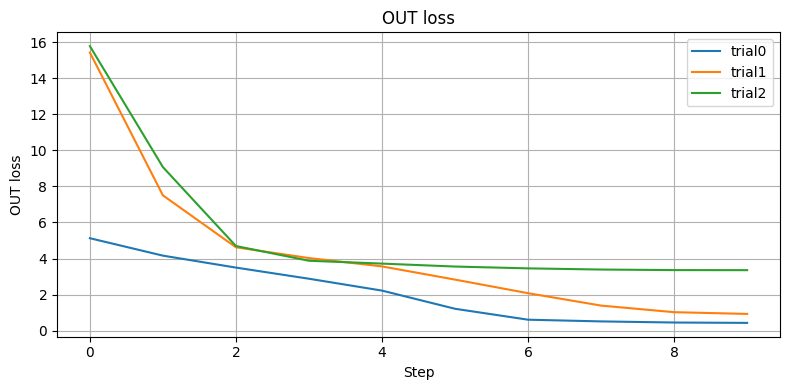

In [6]:
models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models0"
os.makedirs(f"{models_dir}/plots", exist_ok=True)

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["train", "val"],
    subkeys=["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "ic_loss", "weighted_loss"],
    figsize=(12, 5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/losses.png"
)

print_model_info(f"{models_dir}/trial0")

models_dict = {
    "trial0": load_stats(f"{models_dir}/trial0"),
    "trial1": load_stats(f"{models_dir}/trial1"),
    "trial2": load_stats(f"{models_dir}/trial2")
}
plot_loss_comp(
    stats_dict=models_dict,
    phase="train",
    loss_prefix="out",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/loss_comp.png"
)

### 2nd model selection step
Take the best 3 trials/configurations and perform 50 epochs of training for each of them.

In [7]:
if TRAIN:
    n_best = 3
    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models0"

    fourier_features = []
    lr_init = []

    for i in range(n_best):
        checkpoint = torch.load(f"{models_dir}/trial{i}/model.pth", weights_only=False)
        fourier_features.append(checkpoint["fourier_features"])
        lr_init.append(checkpoint["lr_init"])

    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models1"

    config_dict["models_dir"] = models_dir
    config_dict["epochs"] = min(50, N_EPOCHS)
    config_dict["n_trials"] = 3
    config_dict["suggestions"] = "Off"
    config_dict["n_warmup_steps"] = 1000

    if FOURIER_FEATURES:
        actual["fourier_features"] = fourier_features
    config_dict["Actual"] = actual
    config_dict["learning_rate"] = lr_init
    
    if not ONLY_FINAL_TRAINING:
        start_train(config_dict)

[I 2026-03-28 11:15:46,923] A new study created in memory with name: no-name-551cd649-a6b5-4bb7-99eb-f05405dc0816


batch_size_train = 1024
len(train_dataset) = 14336
batch_size_val = 1024
len(val_dataset) = 4096
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 604
len(train_bc_dataset) = 604
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 200
len(val_bc_dataset) = 200

Epoch: 0, step_prefix: 0
Epoch time: 1.6618084907531738
train weighted loss: 20.91071265084403
train out loss: 3.980391263961792
val weighted loss: 24.67820692062378
val out loss: 4.3268396854400635

Epoch: 1, step_prefix: 14
Epoch time: 1.4357256889343262
train weighted loss: 15.52941267830985
train out loss: 3.728412781442915
val weighted loss: 18.161935329437256
val out loss: 4.046668231487274

Epoch: 2, step_prefix: 28
Epoch time: 1.4823181629180908
train weighted loss: 12.904740061078753
train out loss: 3.2986940145492554
val weighted loss: 14.99038028717041
val out loss: 3.586204767227173

Epoch: 3, step_prefix: 42
Epoch time: 1.398634910583496
train weighted loss: 9.9612468310

[I 2026-03-28 11:18:08,740] Trial 0 finished with value: 0.07723084324970841 and parameters: {}. Best is trial 0 with value: 0.07723084324970841.


val weighted loss: 0.3279903754591942
val out loss: 0.003925484430510551
batch_size_train = 1024
len(train_dataset) = 14336
batch_size_val = 1024
len(val_dataset) = 4096
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 604
len(train_bc_dataset) = 604
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 200
len(val_bc_dataset) = 200

Epoch: 0, step_prefix: 0
Epoch time: 1.416368007659912
train weighted loss: 66.93025425502232
train out loss: 3.9638888154711043
val weighted loss: 79.70563697814941
val out loss: 4.317532896995544

Epoch: 1, step_prefix: 14
Epoch time: 1.510547161102295
train weighted loss: 25.45028591156006
train out loss: 3.993433799062456
val weighted loss: 29.594292640686035
val out loss: 4.334991931915283

Epoch: 2, step_prefix: 28
Epoch time: 1.3780581951141357
train weighted loss: 16.35032640184675
train out loss: 3.947954075677054
val weighted loss: 19.134520053863525
val out loss: 4.281300067901611

Epoch: 3, step_pref

[I 2026-03-28 11:20:30,384] Trial 1 finished with value: 0.14815630950033665 and parameters: {}. Best is trial 0 with value: 0.07723084324970841.


val weighted loss: 1.0382404029369354
val out loss: 0.017352734226733446
batch_size_train = 1024
len(train_dataset) = 14336
batch_size_val = 1024
len(val_dataset) = 4096
batch_size_train_ic = 1024
len(train_ic_dataset) = 1024
batch_size_train_bc = 604
len(train_bc_dataset) = 604
batch_size_val_ic = 512
len(val_ic_dataset) = 512
batch_size_val_bc = 200
len(val_bc_dataset) = 200

Epoch: 0, step_prefix: 0
Epoch time: 1.3435149192810059
train weighted loss: 196.03455679757255
train out loss: 15.192348412105016
val weighted loss: 220.23841857910156
val out loss: 15.590066909790039

Epoch: 1, step_prefix: 14
Epoch time: 1.2649295330047607
train weighted loss: 71.46789223807198
train out loss: 6.9237987995147705
val weighted loss: 83.47834014892578
val out loss: 7.286119818687439

Epoch: 2, step_prefix: 28
Epoch time: 1.2677717208862305
train weighted loss: 43.062975202287944
train out loss: 3.9993442467280795
val weighted loss: 50.9663667678833
val out loss: 4.341485500335693

Epoch: 3, step

[I 2026-03-28 11:22:43,031] Trial 2 finished with value: 0.4767313078045845 and parameters: {}. Best is trial 0 with value: 0.07723084324970841.


val weighted loss: 2.673989236354828
val out loss: 0.020875131711363792
Best trial params: {}
Best trial value: 0.07723084324970841
trialN0 --> trial0: Objective Value = 0.0772
trialN1 --> trial1: Objective Value = 0.1482
trialN2 --> trial2: Objective Value = 0.4767


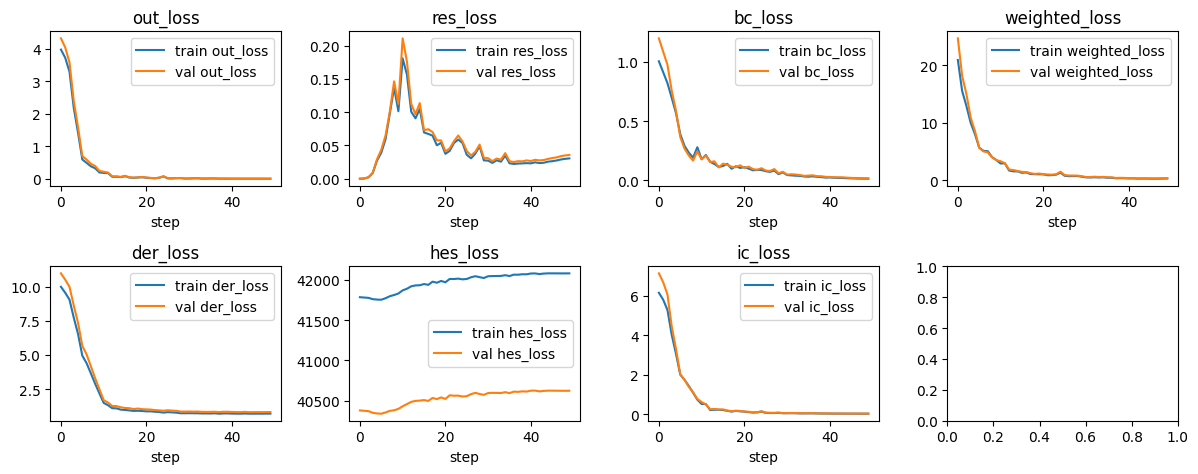


=============== Checkpoint ===============
PDE: Advection-Reaction-Diffusion
PDE parameters in input: []
Time in input: True
Space in input: True
Fourier features: -1
|Input units|: 3
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Forgetting
	EWC: Off
	DWA: Std
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 5.97287130355835
	IC: 7.161591053009033
	RES: 1.4790723323822021
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 1.0
	DER: 1.0
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importances:
----------------------

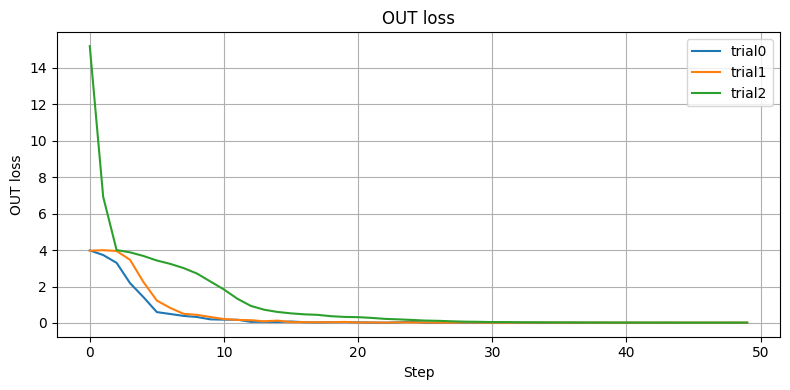

In [8]:
models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models1"
os.makedirs(f"{models_dir}/plots", exist_ok=True)

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["train", "val"],
    subkeys=["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "ic_loss", "weighted_loss"],
    figsize=(12, 5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/losses.png"
)

print_model_info(f"{models_dir}/trial0")

models_dict = {
    "trial0": load_stats(f"{models_dir}/trial0"),
    "trial1": load_stats(f"{models_dir}/trial1"),
    "trial2": load_stats(f"{models_dir}/trial2")
}
plot_loss_comp(
    stats_dict=models_dict,
    phase="train",
    loss_prefix="out",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/loss_comp.png"
)

### 3rd model selection step
Take the best trial/configuration and perform 100 epochs of training.

In [9]:
if TRAIN:
    if train_dataset is not None:
        del train_dataset
        train_dataset = None
    if val_dataset is not None:
        del val_dataset
        val_dataset = None
    if INDEX is None:
        full_dataset = torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets
    else:
        full_dataset = [torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets[INDEX]]
    dev_dataset = load_datasets(full_dataset, indices["dev"], TIME_RESOLUTION)
    del full_dataset
    full_dataset = None
    
    dev_dataset = prepare_dataset(datasets=dev_dataset, time_instants=TIME_INDEXES)

    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models1"
    
    checkpoint = torch.load(f"{models_dir}/trial{0}/model.pth", weights_only=False)
    fourier_features = checkpoint["fourier_features"]
    lr_init = checkpoint["lr_init"]
    
    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
    
    config_dict["models_dir"] = models_dir
    config_dict["epochs"] = N_EPOCHS
    config_dict["n_trials"] = 1
    
    actual["fourier_features"] = fourier_features
    actual["train_dataset"] = dev_dataset
    actual["val_dataset"] = ""
    config_dict["Actual"] = actual
    config_dict["learning_rate"] = lr_init
    config_dict["batch_size"] = min(BATCH_SIZE_DEV, len(dev_dataset))
    start_train(config_dict)

[I 2026-03-28 11:22:48,177] A new study created in memory with name: no-name-401233f2-888f-42f1-ac1a-e64fa41ed232


batch_size_train = 1024
len(train_dataset) = 19456
batch_size_train_ic = 1024
len(train_ic_dataset) = 2048
batch_size_train_bc = 804
len(train_bc_dataset) = 804

Epoch: 0, step_prefix: 0
Epoch time: 2.2142796516418457
train weighted loss: 20.657289705778425
train out loss: 4.170975735313014

Epoch: 1, step_prefix: 19
Epoch time: 2.111610174179077
train weighted loss: 14.951035148219058
train out loss: 3.486477726384213

Epoch: 2, step_prefix: 38
Epoch time: 1.9510273933410645
train weighted loss: 9.4815303902877
train out loss: 2.0541006326675415

Epoch: 3, step_prefix: 57
Epoch time: 2.1292357444763184
train weighted loss: 6.956358959800319
train out loss: 1.0160504861881858

Epoch: 4, step_prefix: 76
Epoch time: 2.1441831588745117
train weighted loss: 5.644562269511976
train out loss: 0.5678490776764719

Epoch: 5, step_prefix: 95
Epoch time: 2.1285386085510254
train weighted loss: 4.549755748949553
train out loss: 0.39472423101726334

Epoch: 6, step_prefix: 114
Epoch time: 2.01039099

[I 2026-03-28 11:44:39,998] Trial 0 finished with value: 0.0022282967961233992 and parameters: {}. Best is trial 0 with value: 0.0022282967961233992.


train weighted loss: 0.008855831711307952
train out loss: 0.0004947632244837127
Best trial params: {}
Best trial value: 0.0022282967961233992
trialN0 --> trial0: Objective Value = 0.0022


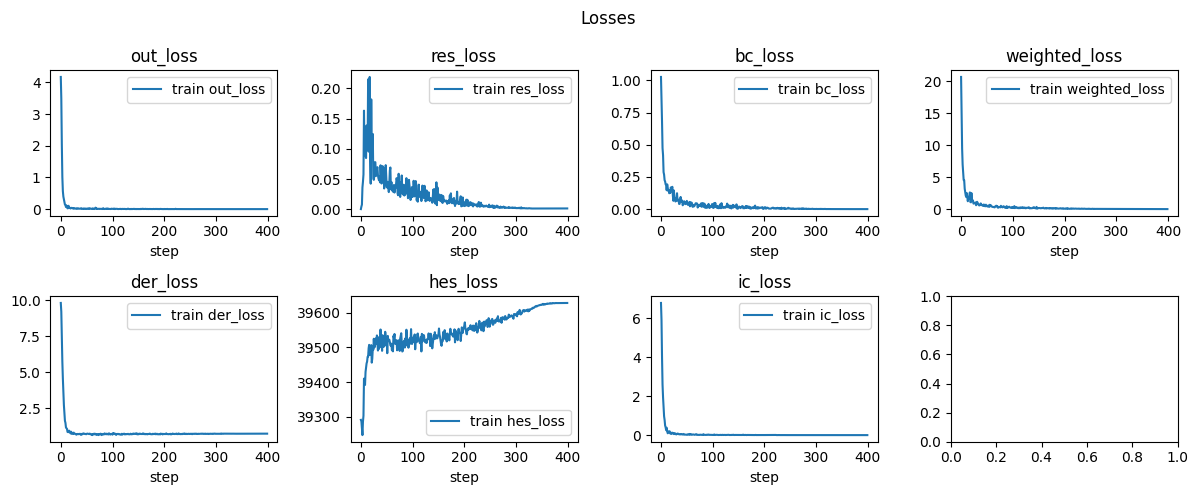


=============== Checkpoint ===============
PDE: Advection-Reaction-Diffusion
PDE parameters in input: []
Time in input: True
Space in input: True
Fourier features: -1
|Input units|: 3
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Forgetting
	EWC: Off
	DWA: Std
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 17.034164428710938
	IC: 4.187997817993164
	RES: 1.4463672637939453
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 1.0
	DER: 1.0
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importances:
--------------------

In [10]:
models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
os.makedirs(f"{models_dir}/plots", exist_ok=True)

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["train"],
    subkeys=["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "ic_loss", "weighted_loss"],
    figsize=(12, 5),
    title="Losses",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/losses.png"
)

print_model_info(f"{models_dir}/trial0")

Last res_loss: 0.001309813465923071
Last bc_loss: 0.0002424656559014693
Last ic_loss: 0.0006760176620446146
Last grad norm: 0.12525305151939392


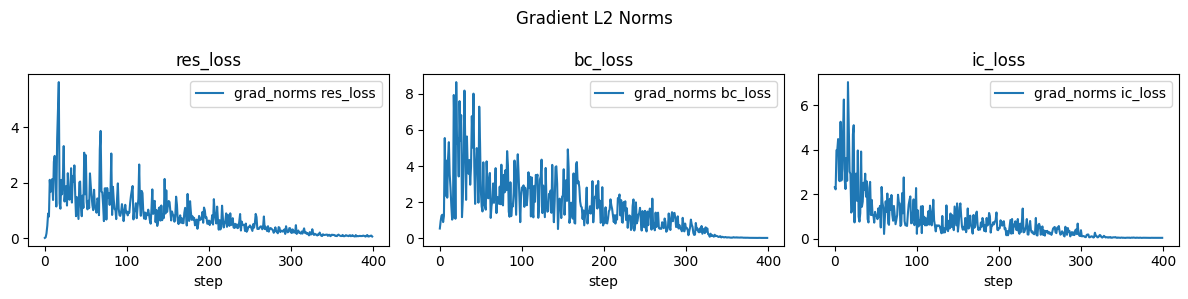

Last value weights res_loss: 1.4463672637939453
Last value weights bc_loss: 17.034164428710938
Last value weights ic_loss: 4.187997817993164


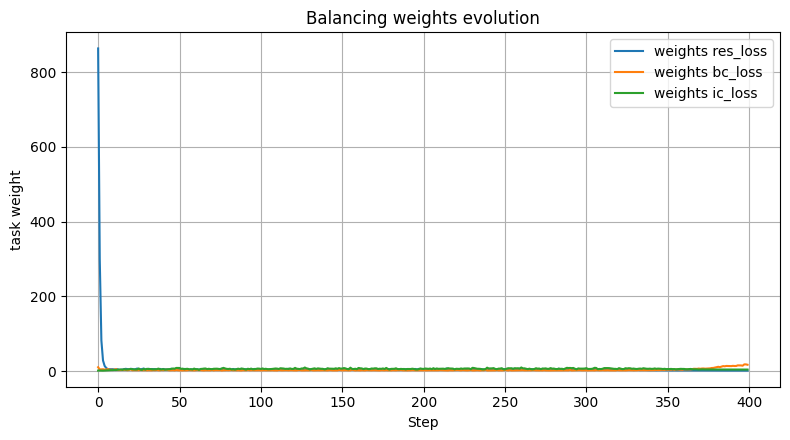

Last value conflicts bc_loss: -0.1804783046245575
Last value conflicts ic_loss: -0.0215433519333601


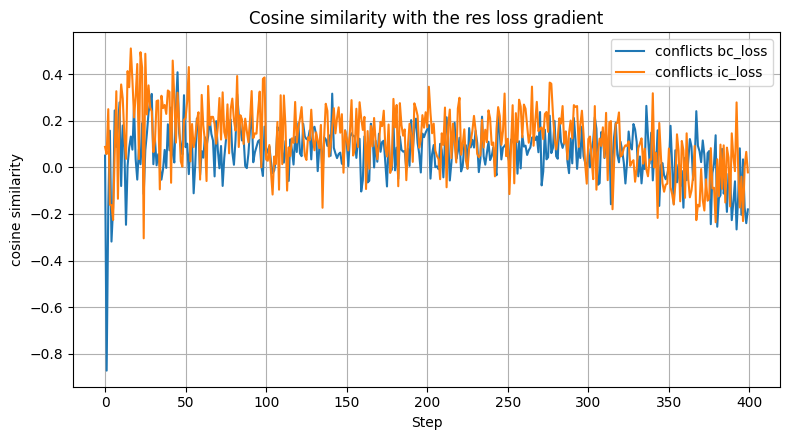

In [11]:
models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
models_dict = {"trial0": load_stats(f"{models_dir}/trial0")}

print(f"Last res_loss: {models_dict['trial0']['train']['res_loss'][-1]}")
print(f"Last bc_loss: {models_dict['trial0']['train']['bc_loss'][-1]}")
print(f"Last ic_loss: {models_dict['trial0']['train']['ic_loss'][-1]}")
print(f"Last grad norm: {models_dict['trial0']['train_loss_grad_norm'][-1][0]}")

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["grad_norms"],
    subkeys=["res_loss", "bc_loss", "ic_loss"],
    figsize=(12, 3),
    title="Gradient L2 Norms",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/grad_norms.png"
)
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["weights"],
    subkeys=["res_loss", "bc_loss", "ic_loss"],
    ylabel="task weight",
    title="Balancing weights evolution",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/weights.png"
)
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["conflicts"],
    subkeys=["bc_loss", "ic_loss"],
    ylabel="cosine similarity",
    title="Cosine similarity with the res loss gradient",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/conflicts.png"
)

### Predictions vs real values

Params 1


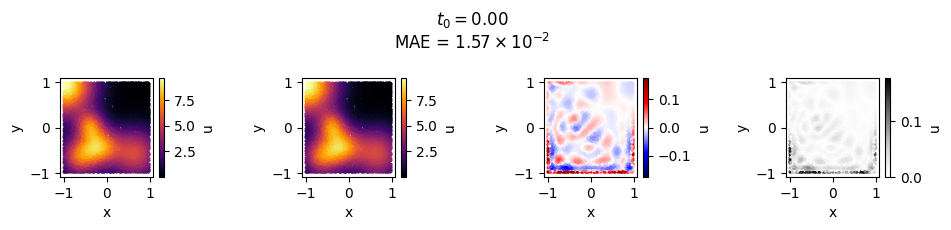

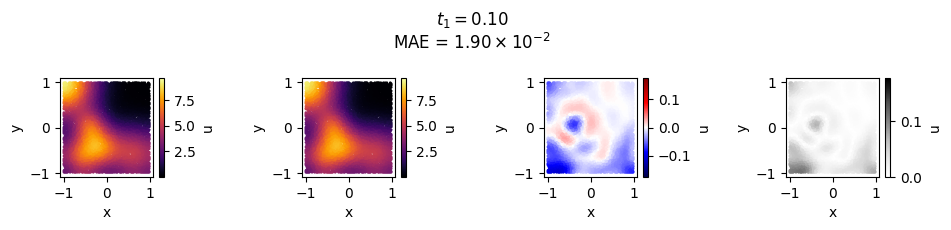

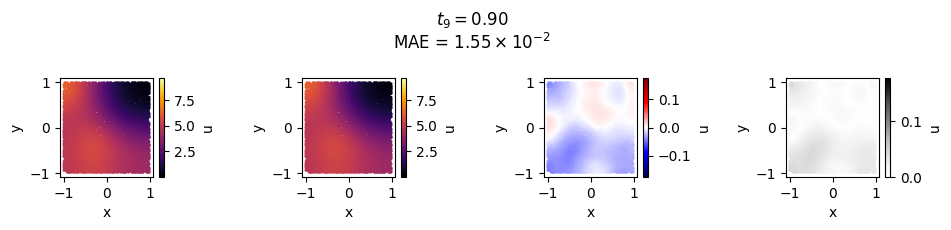

In [12]:
if CROSS_THE_RUBICON:
    times = [0, 1, 9]
    param_indices = [INDEX] # [D_INDEX] [IC_INDEX]

    if "IC" in FIXED and "D" in FIXED:
        param_indices = [INDEX]

    if dev_dataset is not None:
        del dev_dataset
        dev_dataset = None
    datasets = torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets

    trues = [[[] for t in range(max(times)+1)] for i in range(max(param_indices)+1)]
    
    for i in param_indices:
        trues[i] = datasets[i].datasets
    del datasets

    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    best_model = resume_model(model_path=f"{models_dir}/trial0/model.pth", device="cpu")

    vmins = []
    vmaxs = []

    for i in param_indices:
        vmins.append(min([trues[i][t].tensors[U].min() for t in times]))
        vmaxs.append(max([trues[i][t].tensors[U].max() for t in times]))
    vmin = min(vmins)
    vmax = max(vmaxs)

    differences = [[[] for t in range(max(times)+1)] for i in range(max(param_indices)+1)]

    for i in param_indices:
        for t in times:
            differences[i][t] = compute_prediction_difference(model=best_model, dataset=trues[i][t], signed=True)

    vmins = []
    vmaxs = []

    for i in param_indices:
        vmins.append(min([differences[i][t].tensors[U].min() for t in times]))
        vmaxs.append(max([differences[i][t].tensors[U].max() for t in times]))
    vmin_diff = min(vmins)
    vmax_diff = max(vmaxs)
    v_diff = max(abs(vmin_diff), abs(vmax_diff))

    figsize = (9.8, 2.3)
    
    for i in param_indices:
        print(f"Params {i}")
        for t in times:

            prediction = compute_prediction(model=best_model, dataset=trues[i][t])
            abs_difference = compute_prediction_difference(model=best_model, dataset=trues[i][t], signed=False)
            mean_abs_difference = torch.mean(abs_difference.tensors[U])
            mae = mean_abs_difference.item()

            value = format(mae, ".2e").split('e')[0]
            exponent = format(mae, ".2e").split('e')[1]

            plot_points(
                dataset=[trues[i][t], prediction, differences[i][t], abs_difference],
                points_idx=X,
                labels_idx=U,
                cmap=["inferno", "inferno", "seismic", "Greys"],
                figsize=figsize,
                vmin=2*[vmin]+[-v_diff]+[0],
                vmax=2*[vmax]+[v_diff]+[v_diff],
                title=f"$t_{{{t}}} = {{{trues[i][t].tensors[TIMES][0].item():.2f}}}$\nMAE = ${{{value}}} \\times 10^{{{int(exponent)}}}$",
                save=True,
                dst_file=f"{models_dir}/plots/Task{i}Time{t}.png",
                show=True
            )

In [13]:
if CROSS_THE_RUBICON and False:
    param_indices = [0, 1, 2] # [D_INDEX] [IC_INDEX]

    if "IC" in FIXED and "D" in FIXED:
        param_indices = [INDEX]

    if dev_dataset is not None:
        del dev_dataset
        dev_dataset = None
    dataset = torch.load(f"{PDE}/{DATA}/full_datasets.pth", weights_only=False).datasets
    dataset = [dataset[i] for i in param_indices]

    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{TRAIN_BC}BC_{LR_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    best_model = resume_model(model_path=f"{models_dir}/trial0/model.pth", device="cpu")

    for j, cds in tqdm(zip(param_indices, dataset), total=len(param_indices)):
        trues = []
        predictions = []
        differences = []
        for i in range(0, len(cds.datasets)):
            ds = cds.datasets[i]
            trues.append(ds)
            predictions.append(compute_prediction(model=best_model, dataset=ds))
            differences.append(compute_prediction_difference(model=best_model, dataset=ds, signed=False))
        get_animation(dataset=ConcatDataset(trues), figsize=(2, 1.5), filename=f"{models_dir}/plots/true{j}a.gif", save=True)
        get_animation(dataset=ConcatDataset(predictions), figsize=(2, 1.5), filename=f"{models_dir}/plots/predicted{j}a.gif", save=True)
        get_animation(dataset=ConcatDataset(differences), figsize=(2, 1.5), filename=f"{models_dir}/plots/difference{j}a.gif", save=True, cmap="Greys")

        #get_animation(dataset=ConcatDataset(trues[1:]), filename=f"{models_dir}/plots/true{j}b.gif", save=True)
        #get_animation(dataset=ConcatDataset(predictions[1:]), filename=f"{models_dir}/plots/predicted{j}b.gif", save=True)
        #get_animation(dataset=ConcatDataset(differences[1:]), filename=f"{models_dir}/plots/difference{j}b.gif", save=True, cmap="Greys")

        